In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [9]:
df = pd.read_csv('bodyPerformance.csv')

# Ingeniería de variables
df['bmi'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
df['relative_grip'] = df['gripForce'] / df['weight_kg']

# Quitamos a las mujeres del dataset para comparar mujeres
df = df[df['gender'] != 'M']
df.drop(columns=['gender'], inplace=True)

# Dividimos entre datos y objetivo
X = df.drop('class', axis=1)
y = df['class']

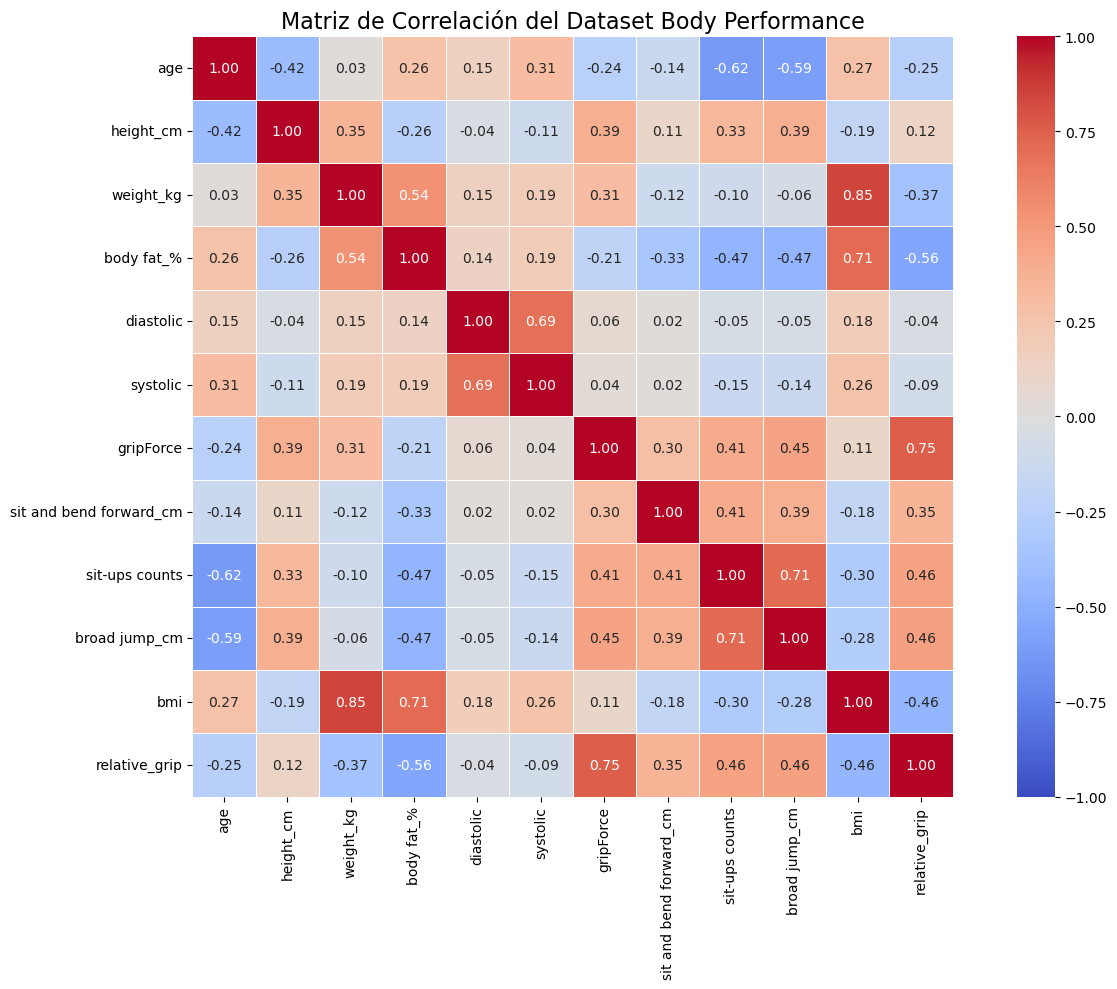

In [10]:
matriz_corr = df.drop(columns=['class']).corr()
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_corr, 
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True)
plt.title('Matriz de Correlación del Dataset Body Performance', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
# Cambiamos de categorico a enteros los objetivos
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Separamos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Diseñamos la arquitectura de la red MLP
model = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(4, activation='softmax')
])

c:\Users\miguelmr\anaconda3\envs\general\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Modificamos el learning rate si se estanca el aprendizaje
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# Paramos si hay sobreajuste
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# Entrenamos la red
history = model.fit(X_train_scaled,
                    y_train,
                    epochs=200,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[reduce_lr, early_stop],
                    verbose=1)

Epoch 1/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4929 - loss: 1.3630 - val_accuracy: 0.3477 - val_loss: 1.1820 - learning_rate: 0.0010
Epoch 2/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5626 - loss: 1.0664 - val_accuracy: 0.4137 - val_loss: 1.1348 - learning_rate: 0.0010
Epoch 3/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5911 - loss: 0.9555 - val_accuracy: 0.5584 - val_loss: 0.9339 - learning_rate: 0.0010
Epoch 4/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6094 - loss: 0.8928 - val_accuracy: 0.6574 - val_loss: 0.8237 - learning_rate: 0.0010
Epoch 5/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6373 - loss: 0.8694 - val_accuracy: 0.7005 - val_loss: 0.7639 - learning_rate: 0.0010
Epoch 6/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6526 - loss: 0.8233 - val_accuracy: 0.7030 - val_loss: 0.7273 - learning_rate: 0.0010
Epoch 7/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6607 - loss:

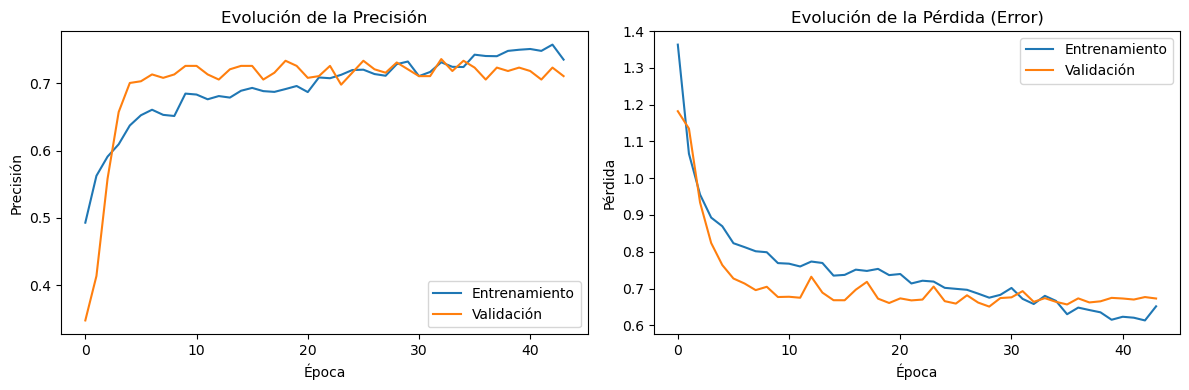


Mejor precisión de MLP: 0.7099
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Datos del aprendizaje
              precision    recall  f1-score   support

           A       0.69      0.86      0.77       269
           B       0.55      0.48      0.51       239
           C       0.67      0.71      0.69       225
           D       0.95      0.77      0.85       253

    accuracy                           0.71       986
   macro avg       0.71      0.70      0.70       986
weighted avg       0.72      0.71      0.71       986



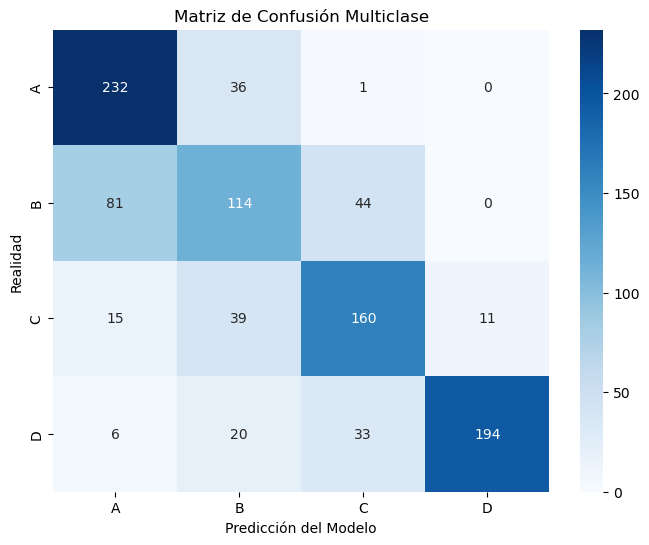

In [14]:
plt.figure(figsize=(12, 4))

# Gráfica Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución de la Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Gráfica Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución de la Pérdida (Error)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# Comprobamos resultados
loss, final_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nMejor precisión de MLP: {final_acc:.4f}")

# Predecimos los datos de test
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Datos de aprendizaje
nombres_clases = label_encoder.inverse_transform([0, 1, 2, 3]) # Recupera 'A', 'B', 'C', 'D'
print("\nDatos del aprendizaje")
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title("Matriz de Confusión Multiclase")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Realidad")
plt.show()